In [25]:
import scanpy as sc
import pandas as pd
import numpy as np
import random
from scipy import sparse
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import pseudobulk

In [166]:
adata = sc.read_h5ad("/project/imoskowitz/yubin/1-sc_practice/Data/SmoNull_Brain_system.h5ad")

In [167]:
adata

AnnData object with n_obs × n_vars = 38311 × 33696
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Condition', 'Library.ident', 'Sample', 'Replicate', 'percent.mt', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.1', 'seurat_clusters', 'doublet_finder', 'doublet_status', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'SCT_snn_res.1', 'SCT_snn_res.4', 'Extended_mouse_gastrulation_label', 'System', 'ClusterSystem', 'total_counts', 'size_factors', 'Celltype', 'leiden_0_25_log1p', 'leiden_0_25_scran', 'leiden_0_25_pearson', 'leiden_0_5_log1p', 'leiden_0_5_scran', 'leiden_0_5_pearson', 'leiden_1_log1p', 'leiden_1_scran', 'leiden_1_pearson', 'leiden_2_log1p', 'leiden_2_scran', 'leiden_2_pearson', 'leiden_3_log1p', 'leiden_3_scran', 'leiden_3_pearson', 'leiden_5_log1p', 'leiden_5_scran', 'leiden_5_pearson', 'manual_celltype_annotation'
    var: 'features', 'highly_variable_log1p', 'highly_variable_nbatches_log1p', 'highly_variable_intersection_log1p', 'mean', 'std', 'means', 'variances', 'r

In [128]:
# Display the count for each cell type and by condition (manually labeled)
pd.crosstab(adata.obs["manual_celltype_annotation"], adata.obs["Condition"])

Condition,Control,SmoNull
manual_celltype_annotation,,
Forebrain,3419,2910
Hindbrain,4502,6505
Midbrain,3220,3663
Midline,4127,68


Pseudobulk steps:

0. Choose a cluster/celltype
1. Group by Condition + replicate
2. Find total of gene count within the group for each gene (axis = 0)
3. Create a new anndata that stores the total count, as well as gene name. Should have format like this:

Condition + replicate| Gene1 | Gene 2 | ... | Gene n
---------------------|-------|--------|-----|--------
Control_1 | 0 | 1 | ... | 2
Smo_null | 0 | 100 | ... | 23

4. Make sure you include metadatas for obs such as the cell type, cluster, condition, replicate, etc

In [129]:
print(len(adata[adata.obs["Condition"]=="Control"].obs["Sample"].cat.categories))
print(len(adata[adata.obs["Condition"]=="SmoNull"].obs["Sample"].cat.categories))

3
3


In [130]:
adata[adata.obs["Sample"] == "Sample1"].obs.Condition.unique()

['Control']
Categories (1, object): ['Control']

In [131]:
[adata.obs["Condition"].iloc[0]]

['Control']

# Start of  Pseudobulk

In [168]:
# Convert X to raw
adata.X = adata.layers["raw_counts"]

In [169]:
hindbrain_subset = adata[adata.obs.manual_celltype_annotation == "Hindbrain"]

In [170]:
hindbrain_pb = pseudobulk.run_pseudobulk(hindbrain_subset, by = "Sample", metadatas = "manual_celltype_annotation")

In [160]:
hindbrain_dds = pseudobulk.run_deseq(hindbrain_pb, "~Condition", min_cells=0)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.89 seconds.

Fitting dispersion trend curve...
... done in 0.74 seconds.

Fitting MAP dispersions...
... done in 3.32 seconds.

Fitting LFCs...
... done in 2.41 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



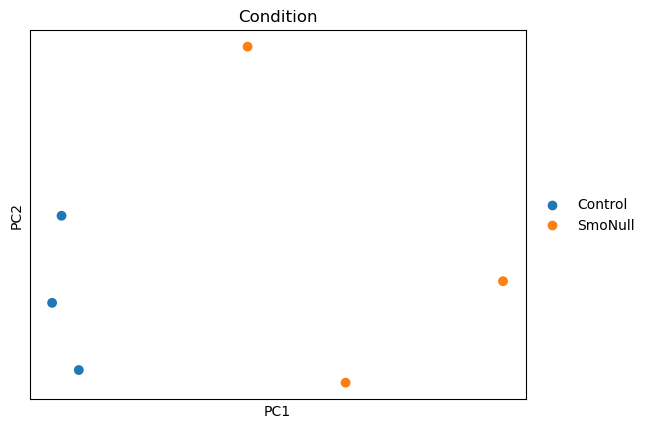

In [153]:
sc.tl.pca(hindbrain_dds)
sc.pl.pca(hindbrain_dds, color = "Condition", size=200)

In [162]:
stat_res = DeseqStats(hindbrain_dds, n_cpus=8, contrast=("Condition", "Control", "SmoNull"))

In [163]:
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Condition Control vs SmoNull
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4                489.923797       -0.173432  0.145978 -1.188072  0.234805   
Gm1992               23.294824       -0.051467  0.418526 -0.122972  0.902129   
Gm19938              12.049165       -0.394003  0.563621 -0.699056  0.484517   
Gm37381               0.504649       -2.149422  3.358629 -0.639970  0.522192   
Rp1                   7.060131       -0.226565  0.788342 -0.287394  0.773811   
...                        ...             ...       ...       ...       ...   
ENSMUSG00000095523    0.000000             NaN       NaN       NaN       NaN   
ENSMUSG00000095475    0.000000             NaN       NaN       NaN       NaN   
ENSMUSG00000094855    0.000000             NaN       NaN       NaN       NaN   
ENSMUSG00000095019    0.000000             NaN       NaN       NaN       NaN   
ENSMUSG00000095041  299.150421       -0.544666  0.257

... done in 11.84 seconds.



In [156]:
de = stat_res.results_df

In [157]:
de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Xkr4,489.923797,-0.173432,0.145978,-1.188072,0.234805,0.441981
Gm1992,23.294824,-0.051467,0.418526,-0.122972,0.902129,0.953237
Gm19938,12.049165,-0.394003,0.563621,-0.699056,0.484517,0.689538
Gm37381,0.504649,-2.149422,3.358629,-0.639970,0.522192,NaN
Rp1,7.060131,-0.226565,0.788342,-0.287394,0.773811,NaN
...,...,...,...,...,...,...
ENSMUSG00000095500,0.375806,0.649481,3.541146,0.183410,0.854477,NaN
Csprs,0.132808,-0.312305,4.427542,-0.070537,0.943766,NaN
ENSMUSG00000096808,0.885288,-1.580838,2.209688,-0.715412,0.474354,NaN
ENSMUSG00000095742,10.259770,0.051710,0.588223,0.087909,0.929949,0.966775


In [158]:
# de.to_csv("DEG_Hindbrain_Control_vs_SmoNull_filter_10_cells")

Filter out genes present in less than i pseudobulk samples

In [ ]:
for i in range(7):
    hindbrain_dds = pseudobulk.run_deseq(hindbrain_pb, "~Condition", min_cells=i)
    stat_res = DeseqStats(hindbrain_dds, n_cpus=8, contrast=("Condition", "Control", "SmoNull"))
    stat_res.summary()
    de = stat_res.results_df
    de.to_csv("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/DataFrames/Post-pseudobulk-filter/DEG_Hindbrain_Control_vs_SmoNull_filter_" + str(i) + "_cells")
    print(len(de))

Filtering out genes present in less than i cells before pseudobulking

In [181]:
print(hindbrain_subset.X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 35036790 stored elements and shape (11007, 33696)>
  Coords	Values
  (0, 18)	1.0
  (0, 22)	2.0
  (0, 25)	1.0
  (0, 42)	3.0
  (0, 43)	1.0
  (0, 49)	4.0
  (0, 68)	1.0
  (0, 78)	1.0
  (0, 123)	1.0
  (0, 125)	2.0
  (0, 136)	3.0
  (0, 150)	2.0
  (0, 156)	2.0
  (0, 174)	1.0
  (0, 205)	2.0
  (0, 227)	1.0
  (0, 230)	17.0
  (0, 251)	1.0
  (0, 295)	2.0
  (0, 299)	1.0
  (0, 308)	1.0
  (0, 313)	1.0
  (0, 338)	1.0
  (0, 346)	1.0
  (0, 350)	1.0
  :	:
  (11006, 32766)	3.0
  (11006, 32767)	1.0
  (11006, 32768)	2.0
  (11006, 32771)	1.0
  (11006, 32786)	1.0
  (11006, 32804)	1.0
  (11006, 32811)	3.0
  (11006, 32818)	5.0
  (11006, 32822)	1.0
  (11006, 32831)	1.0
  (11006, 32836)	1.0
  (11006, 32840)	2.0
  (11006, 32843)	1.0
  (11006, 32860)	2.0
  (11006, 32863)	1.0
  (11006, 32866)	1.0
  (11006, 32891)	3.0
  (11006, 32906)	1.0
  (11006, 32909)	2.0
  (11006, 33631)	3.0
  (11006, 33634)	3.0
  (11006, 33637)	1.0
  (11006, 33638)	2.0
  (11006, 3364

In [182]:
for i in range(5):
    hindbrain_pb = pseudobulk.run_pseudobulk(hindbrain_subset, by = "Sample", metadatas = "manual_celltype_annotation", min_cells=i)
    hindbrain_dds = pseudobulk.run_deseq(hindbrain_pb, "~Condition", min_cells=0)
    stat_res = DeseqStats(hindbrain_dds, n_cpus=8, contrast=("Condition", "Control", "SmoNull"))
    stat_res.summary()
    de = stat_res.results_df
    de.to_csv("/project/imoskowitz/yubin/1-sc_practice/Differential_Gene_Analysis/DataFrames/DEG_Hindbrain_Control_vs_SmoNull_pre_filter_" + str(i) + "_cells")
    print(len(de))

/home/yubin/.conda/envs/scRNAseq_python/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.93 seconds.

Fitting dispersion trend curve...
... done in 0.56 seconds.

Fitting MAP dispersions...
... done in 3.49 seconds.

Fitting LFCs...
... done in 2.24 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 12.02 seconds.



Log2 fold change & Wald test p-value: Condition Control vs SmoNull
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4                489.923797       -0.173432  0.145978 -1.188072  0.234805   
Gm1992               23.294824       -0.051467  0.418526 -0.122972  0.902129   
Gm19938              12.049165       -0.394003  0.563621 -0.699056  0.484517   
Gm37381               0.504649       -2.149422  3.358629 -0.639970  0.522192   
Rp1                   7.060131       -0.226565  0.788342 -0.287394  0.773811   
...                        ...             ...       ...       ...       ...   
ENSMUSG00000095523    0.000000             NaN       NaN       NaN       NaN   
ENSMUSG00000095475    0.000000             NaN       NaN       NaN       NaN   
ENSMUSG00000094855    0.000000             NaN       NaN       NaN       NaN   
ENSMUSG00000095019    0.000000             NaN       NaN       NaN       NaN   
ENSMUSG00000095041  299.150421       -0.544666  0.257

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 3.12 seconds.

Fitting dispersion trend curve...
... done in 0.57 seconds.

Fitting MAP dispersions...
... done in 3.37 seconds.

Fitting LFCs...
... done in 2.32 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 11.87 seconds.



...

Log2 fold change & Wald test p-value: Condition Control vs SmoNull
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4                489.923797       -0.173436  0.146054 -1.187484  0.235037   
Gm1992               23.294824       -0.051404  0.421162 -0.122052  0.902858   
Gm19938              12.049165       -0.394036  0.567454 -0.694393  0.487436   
Gm37381               0.504649       -2.149261  3.379678 -0.635937  0.524818   
Rp1                   7.060131       -0.226287  0.793209 -0.285280  0.775429   
...                        ...             ...       ...       ...       ...   
ENSMUSG00000079190    0.265616       -1.215036  4.324039 -0.280996  0.778714   
ENSMUSG00000095500    0.375806        0.649481  3.567591  0.182050  0.855543   
ENSMUSG00000096808    0.885288       -1.581067  2.223052 -0.711215  0.476951   
ENSMUSG00000095742   10.259770        0.051623  0.592304  0.087156  0.930547   
ENSMUSG00000095041  299.150421       -0.544661  0.257

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.95 seconds.

Fitting dispersion trend curve...
... done in 0.51 seconds.

Fitting MAP dispersions...
... done in 3.47 seconds.

Fitting LFCs...
... done in 2.50 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 13.05 seconds.



Log2 fold change & Wald test p-value: Condition Control vs SmoNull
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4                 489.923797       -0.173428  0.145886 -1.188790  0.234522   
Gm1992                23.294824       -0.051370  0.422581 -0.121563  0.903245   
Gm19938               12.049165       -0.394057  0.569978 -0.691356  0.489342   
Gm37381                0.504649       -2.149281  3.377032 -0.636441  0.524489   
Rp1                    7.060131       -0.226216  0.794462 -0.284741  0.775842   
...                         ...             ...       ...       ...       ...   
mt-Nd6               191.468738       -0.126748  0.485363 -0.261140  0.793985   
mt-Cytb             1630.586234        0.386753  0.166605  2.321373  0.020267   
ENSMUSG00000096808     0.885288       -1.581212  2.231693 -0.708526  0.478619   
ENSMUSG00000095742    10.259770        0.051557  0.595465  0.086583  0.931003   
ENSMUSG00000095041   299.150421       -0.5

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.96 seconds.

Fitting dispersion trend curve...
... done in 0.51 seconds.

Fitting MAP dispersions...
... done in 3.50 seconds.

Fitting LFCs...
... done in 2.19 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 12.87 seconds.



Log2 fold change & Wald test p-value: Condition Control vs SmoNull
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
Xkr4                 489.923797       -0.173419  0.145716 -1.190115  0.234001   
Gm1992                23.294824       -0.051373  0.422455 -0.121606  0.903211   
Gm19938               12.049165       -0.394059  0.570113 -0.691193  0.489444   
Gm37381                0.504649       -2.149359  3.366753 -0.638407  0.523209   
Rp1                    7.060131       -0.226281  0.793313 -0.285236  0.775464   
...                         ...             ...       ...       ...       ...   
mt-Nd6               191.468738       -0.126748  0.485363 -0.261140  0.793985   
mt-Cytb             1630.586234        0.386753  0.165934  2.330764  0.019766   
ENSMUSG00000096808     0.885288       -1.581218  2.232065 -0.708411  0.478690   
ENSMUSG00000095742    10.259770        0.051548  0.595930  0.086500  0.931069   
ENSMUSG00000095041   299.150421       -0.5